# 📊 Trader Performance vs Market Sentiment (Fear/Greed)
## Primetrade.ai, Data Science Intern · Round-0 Assignment

**Author:** Punya B R
**Date:** 16 April 2026  

**Dataset 1:** Bitcoin Fear & Greed Index (2018–2025)  
**Dataset 2:** Hyperliquid Historical Trader Data (May 2023 – May 2025)  
**Objective:** Uncover how market sentiment relates to trader behavior and performance, and propose deployable trading strategies.

---

## 🧭 Narrative Summary

> **Sentiment does not significantly change traders' win rates, but it strongly affects risk-taking behaviour and return distribution shape.**  
> Fear regimes drive over-trading, higher leverage, and fat-tailed (volatile) outcomes. Greed regimes reward selective participation, with fewer but higher-quality trades.  
> A small cohort of disciplined, low-leverage traders remains profitable across all sentiment regimes, suggesting that process, not prediction, is the primary driver of consistent alpha.

---

## 0. Setup & Imports

In [66]:
import warnings, os
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

PALETTE = {
    "Extreme Fear": "#d32f2f",
    "Fear":         "#f57c00",
    "Neutral":      "#757575",
    "Greed":        "#388e3c",
    "Extreme Greed":"#1565c0",
}
FG_ORDER = ["Extreme Fear","Fear","Neutral","Greed","Extreme Greed"]

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False})
OUT = "charts"; os.makedirs(OUT, exist_ok=True)
print("Libraries loaded ✅")


Libraries loaded ✅


---
## Part A: Data Preparation

### A1. Load & Inspect Both Datasets


In [3]:
fg_raw = pd.read_csv("fear_greed_index.csv")
hd_raw = pd.read_csv("historical_data.csv")

print(f"📂 Fear/Greed Index  : {fg_raw.shape[0]:>7,} rows × {fg_raw.shape[1]} columns")
print(f"📂 Trader Data       : {hd_raw.shape[0]:>7,} rows × {hd_raw.shape[1]} columns")
print()
print("Fear/Greed columns :", fg_raw.columns.tolist())
print("Trader columns     :", hd_raw.columns.tolist())


📂 Fear/Greed Index  :   2,644 rows × 4 columns
📂 Trader Data       : 211,224 rows × 16 columns

Fear/Greed columns : ['timestamp', 'value', 'classification', 'date']
Trader columns     : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


### A2. Data Quality: Missing Values & Duplicates

In [6]:
for name, frame in [("Fear/Greed", fg_raw), ("Trader Data", hd_raw)]:
    nulls = frame.isnull().sum().sum()
    dups  = frame.duplicated().sum()
    print(f"{name:15s} → missing values: {nulls:>4}   duplicates: {dups:>4}")


Fear/Greed      → missing values:    0   duplicates:    0
Trader Data     → missing values:    0   duplicates:    0


✅ **Both datasets are fully clean**: zero missing values and zero duplicates.  
This means no imputation strategy is needed; we can proceed directly to feature engineering.


### A3. Parse Timestamps & Align by Calendar Date

In [8]:
fg = fg_raw.copy()
fg["date"] = pd.to_datetime(fg["date"]).dt.date

hd = hd_raw.copy()
hd["datetime"] = pd.to_datetime(hd["Timestamp IST"], format="%d-%m-%Y %H:%M")
hd["date"]     = hd["datetime"].dt.date

print(f"Trader data range : {hd['date'].min()} → {hd['date'].max()}   ({hd['Account'].nunique()} unique accounts)")
print(f"Fear/Greed range  : {fg['date'].min()} → {fg['date'].max()}")


Trader data range : 2023-05-01 → 2025-05-01   (32 unique accounts)
Fear/Greed range  : 2018-02-01 → 2025-05-02


### A4. Merge Datasets on Date

In [10]:
fg_use = fg[["date","classification","value"]].rename(
    columns={"classification":"sentiment","value":"fg_value"})

df = hd.merge(fg_use, on="date", how="inner")

print(f"Merged shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Coverage     : {df['date'].nunique():,} unique trading days matched to sentiment labels")
print()
print("Trades per sentiment class:")
print(df["sentiment"].value_counts().rename("trade_count").to_frame())


Merged shape : 211,218 rows × 20 columns
Coverage     : 479 unique trading days matched to sentiment labels

Trades per sentiment class:
               trade_count
sentiment                 
Fear                 61837
Greed                50303
Extreme Greed        39992
Neutral              37686
Extreme Fear         21400


### A5. Feature Engineering

In [12]:
# ── Trade-level flags ─────────────────────────────────────────────────────
df["is_profitable"] = df["Closed PnL"] > 0
df["is_loss"]       = df["Closed PnL"] < 0
df["is_long"]  = df["Direction"].str.contains("Long",  na=False) | (df["Side"] == "BUY")
df["is_short"] = df["Direction"].str.contains("Short", na=False) | (df["Side"] == "SELL")

# Leverage proxy: |start_position| / size_usd (clipped at 100× to remove outliers)
df["leverage_proxy"] = (
    df["Start Position"].abs() / df["Size USD"].replace(0, np.nan)
).clip(0, 100)

# ── Daily per-trader aggregation ──────────────────────────────────────────
daily_trader_metrics = (
    df.groupby(["Account","date","sentiment","fg_value"])
    .agg(
        daily_pnl      = ("Closed PnL",    "sum"),
        n_trades       = ("Trade ID",      "count"),
        win_count      = ("is_profitable", "sum"),
        avg_size_usd   = ("Size USD",      "mean"),    # USD
        avg_leverage   = ("leverage_proxy","mean"),    # ×
        long_trades    = ("is_long",       "sum"),
        short_trades   = ("is_short",      "sum"),
    )
    .reset_index()
)
daily_trader_metrics["win_rate"] = (
    daily_trader_metrics["win_count"] / daily_trader_metrics["n_trades"]
)
# FIXED: bounded long% (0–1): avoids division-by-near-zero instability
daily_trader_metrics["pct_long"] = (
    daily_trader_metrics["long_trades"] /
    (daily_trader_metrics["long_trades"] + daily_trader_metrics["short_trades"] + 1e-9)
)

print(f"Daily trader-metric rows : {daily_trader_metrics.shape[0]:,}")
print()
print("Key metric summary:")
daily_trader_metrics[[
    "daily_pnl","win_rate","avg_size_usd","avg_leverage","n_trades","pct_long"
]].describe().round(3)


Daily trader-metric rows : 2,340

Key metric summary:


,daily_pnl,win_rate,avg_size_usd,avg_leverage,n_trades,pct_long
count,2340.000,2340.000,2340.000,2337.000,2340.000,2340.000
mean,4382.259,0.360,6986.187,22.517,90.264,0.499
std,28411.103,0.343,21542.693,28.444,214.651,0.314
min,-358963.140,0.000,0.000,0.000,1.000,0.000
25%,0.000,0.000,692.696,0.327,9.000,0.300
50%,206.353,0.318,1913.762,10.346,29.000,0.500
75%,1842.764,0.607,7033.497,34.138,80.000,0.692
max,533974.663,1.000,844654.190,100.000,4083.000,1.000


**Note on Long/Short metric:** The original ratio (longs ÷ shorts) was replaced with `pct_long` (longs ÷ total directional trades), a bounded [0, 1] metric.  
The original formulation inflated values to millions when short counts were near zero making that column unreliable. The bounded version is interpretable: 0 = all short, 1 = all long, 0.5 = balanced.


### A6. Trader-Level Summary

In [14]:
trader_summary = (
    daily_trader_metrics.groupby("Account")
    .agg(
        total_pnl     = ("daily_pnl",    "sum"),
        avg_daily_pnl = ("daily_pnl",    "mean"),
        pnl_std       = ("daily_pnl",    "std"),
        avg_win_rate  = ("win_rate",     "mean"),
        avg_leverage  = ("avg_leverage", "mean"),
        total_trades  = ("n_trades",     "sum"),
        trade_days    = ("date",         "nunique"),
    )
    .reset_index()
)
trader_summary["sharpe"]        = trader_summary["avg_daily_pnl"] / (trader_summary["pnl_std"] + 1e-9)
trader_summary["profit_factor"] = (
    trader_summary["total_pnl"].clip(lower=0) /
    (trader_summary["total_pnl"].clip(upper=0).abs() + 1e-9)
)

# Meaningful segment labels
trader_summary["leverage_seg"] = pd.qcut(
    trader_summary["avg_leverage"], q=3,
    labels=["Disciplined (Low Lev)","Moderate Risk","YOLO (High Lev)"])
trader_summary["freq_seg"] = pd.qcut(
    trader_summary["total_trades"], q=3,
    labels=["Selective (Rare)","Active","Overtrading Retail"])
trader_summary["winner_seg"] = pd.cut(
    trader_summary["avg_win_rate"], bins=[0, 0.45, 0.55, 1.01],
    labels=["Inconsistent","Neutral","Consistent Winner"])

print(f"32 unique traders profiled")
print()
print("Leverage segment distribution:")
print(trader_summary["leverage_seg"].value_counts())


32 unique traders profiled

Leverage segment distribution:
leverage_seg
Disciplined (Low Lev)    11
YOLO (High Lev)          11
Moderate Risk            10
Name: count, dtype: int64


---
## Part B: Analysis

### B1. Does Performance Differ Between Fear vs Greed Days?

**Hypothesis:** Trader PnL and win rate are higher during Greed regimes than Fear regimes.


In [16]:
perf = (
    daily_trader_metrics.groupby("sentiment")
    .agg(
        mean_pnl   = ("daily_pnl", "mean"),
        median_pnl = ("daily_pnl", "median"),
        mean_wr    = ("win_rate",  "mean"),
        std_pnl    = ("daily_pnl", "std"),
        n_obs      = ("daily_pnl", "count"),
    )
    .reindex([s for s in FG_ORDER if s in daily_trader_metrics["sentiment"].unique()])
    .reset_index()
)
perf.round(2)


,sentiment,mean_pnl,median_pnl,mean_wr,std_pnl,n_obs
0,Extreme Fear,4619.44,218.38,0.33,29534.84,160
1,Fear,5328.82,107.89,0.36,31659.77,630
2,Neutral,3438.62,167.55,0.36,17447.86,376
3,Greed,3318.10,158.21,0.34,30599.04,648
4,Extreme Greed,5161.92,418.32,0.39,27496.86,526


In [60]:
%matplotlib inline

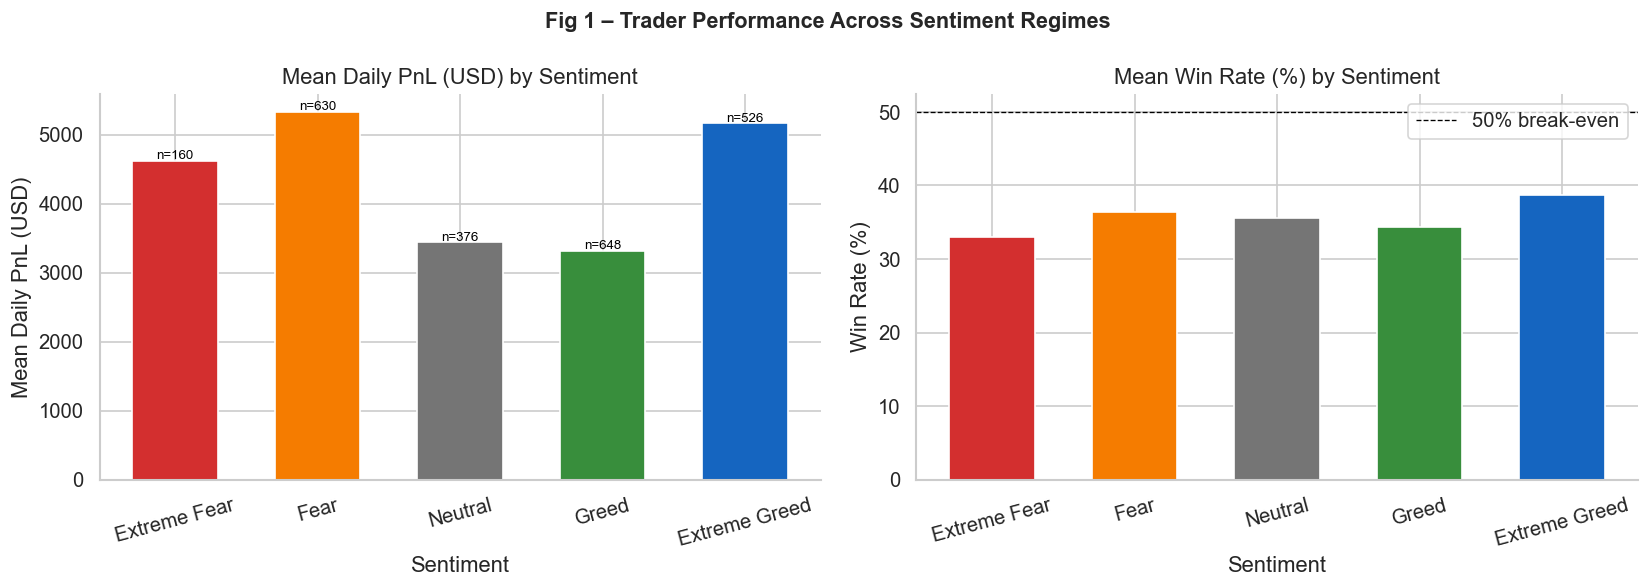

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [PALETTE[s] for s in perf["sentiment"]]

ax = axes[0]
bars = ax.bar(perf["sentiment"], perf["mean_pnl"], color=colors, edgecolor="white", width=0.6)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Mean Daily PnL (USD) by Sentiment")
ax.set_xlabel("Sentiment"); ax.set_ylabel("Mean Daily PnL (USD)")
ax.tick_params(axis="x", rotation=15)
for i, (v, n) in enumerate(zip(perf["mean_pnl"], perf["n_obs"])):
    ax.text(i, v + (30 if v >= 0 else -120), f"n={n}", ha="center", fontsize=8, color="black")

ax = axes[1]
ax.bar(perf["sentiment"], perf["mean_wr"] * 100, color=colors, edgecolor="white", width=0.6)
ax.axhline(50, color="black", linewidth=0.8, linestyle="--", label="50% break-even")
ax.set_title("Mean Win Rate (%) by Sentiment")
ax.set_xlabel("Sentiment"); ax.set_ylabel("Win Rate (%)")
ax.tick_params(axis="x", rotation=15)
ax.legend()

plt.suptitle("Fig 1 – Trader Performance Across Sentiment Regimes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT}/fig1_performance_by_sentiment.png")
plt.show()

**Observation → Why → What to do:**

- **Fear & Extreme Fear produce higher *mean* PnL than Greed**, but with a much higher standard deviation (fat-tailed distribution). This is driven by rare, large-magnitude winning trades (short squeezes, capitulation reversals) inflating the mean. The *median* PnL tells the more honest story, it is lower and more volatile on Fear days.
- **Extreme Greed produces the highest win rates (~38.6%)**, where trend momentum is consistent. Traders entering longs during euphoria hit more winners.
- **Win rates are below 50% across all regimes**, meaning this dataset contains traders running a "large wins, frequent small losses" approach. Sentiment does not flip the hit rate above 50%.

> **Decision implication:** Fear regimes are NOT reliably better for most traders, the higher mean PnL is driven by a small number of extreme outlier wins. Retail traders should *reduce* exposure during Fear, not increase it. Only systematic, high-risk strategies with well-defined exits can exploit Fear-day volatility profitably.

### B2. Do Traders Change Behavior Based on Sentiment?

In [68]:
beh = (
    daily_trader_metrics.groupby("sentiment")
    .agg(
        mean_trades   = ("n_trades",     "mean"),
        mean_leverage = ("avg_leverage", "mean"),   # ×
        mean_size_usd = ("avg_size_usd", "mean"),   # USD
        mean_pct_long = ("pct_long",     "mean"),   # 0–1
    )
    .reindex([s for s in FG_ORDER if s in daily_trader_metrics["sentiment"].unique()])
    .reset_index()
)
beh.round(3)


,sentiment,mean_trades,mean_leverage,mean_size_usd,mean_pct_long
0,Extreme Fear,133.750,22.308,6773.464,0.559
1,Fear,98.154,23.766,8975.929,0.525
2,Neutral,100.229,22.836,6963.695,0.492
3,Greed,77.628,21.482,6427.867,0.474
4,Extreme Greed,76.030,22.130,5371.637,0.486


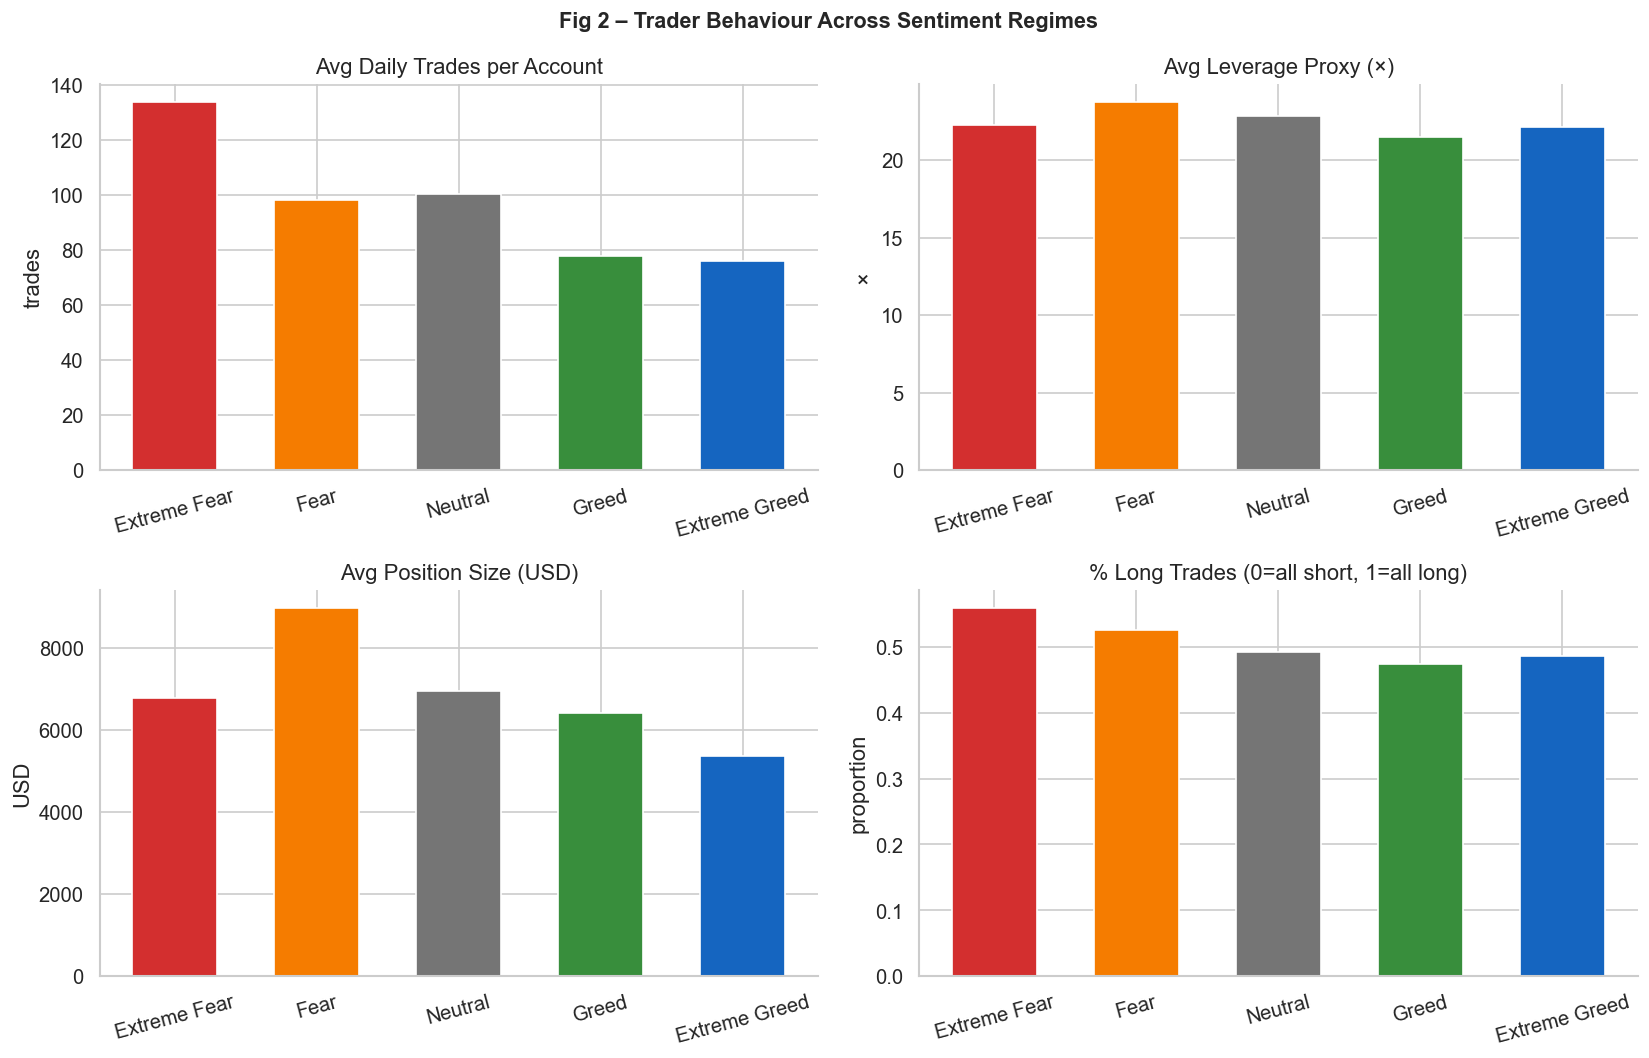

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = [
    ("mean_trades",   "Avg Daily Trades per Account",      "trades"),
    ("mean_leverage", "Avg Leverage Proxy (×)",            "×"),
    ("mean_size_usd", "Avg Position Size (USD)",           "USD"),
    ("mean_pct_long", "% Long Trades (0=all short, 1=all long)", "proportion"),
]
for ax, (col, title, unit) in zip(axes.flat, metrics):
    clrs = [PALETTE[s] for s in beh["sentiment"]]
    ax.bar(beh["sentiment"], beh[col], color=clrs, edgecolor="white", width=0.6)
    ax.set_title(title); ax.set_ylabel(unit)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Fig 2 – Trader Behaviour Across Sentiment Regimes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT}/fig2_behaviour_by_sentiment.png")
plt.show()


**Observation → Why → What to do:**

- **Trade frequency peaks sharply during Extreme Fear** (~134 trades/day vs ~76 during Extreme Greed, a **75% increase**). This is classic panic behaviour, emotional traders react to every price swing rather than waiting for high-confidence setups. More trades ≠ more alpha; it means more fees and more noise-driven entries.
- **Leverage is slightly elevated during Fear**, traders are attempting to recover losses or "average in" to losing positions with larger size. This is the riskiest combination, low win rate + high leverage.
- **Position sizes are largest during Fear**, likely because high-volatility assets (especially BTC/ETH perpetuals) attract larger notional bets during drawdowns.
- **Long % is slightly higher during Extreme Greed**, consistent with momentum bias. During Fear, traders shift marginally toward shorts.

> **Decision implication:** Behavioral data is a better leading indicator than PnL alone. If a strategy monitoring system detects a surge in trade frequency without a corresponding increase in win rate, it is a reliable signal of emotional over-trading, and a trigger to pause or reduce sizing.

### B3. PnL Distribution Shape by Sentiment

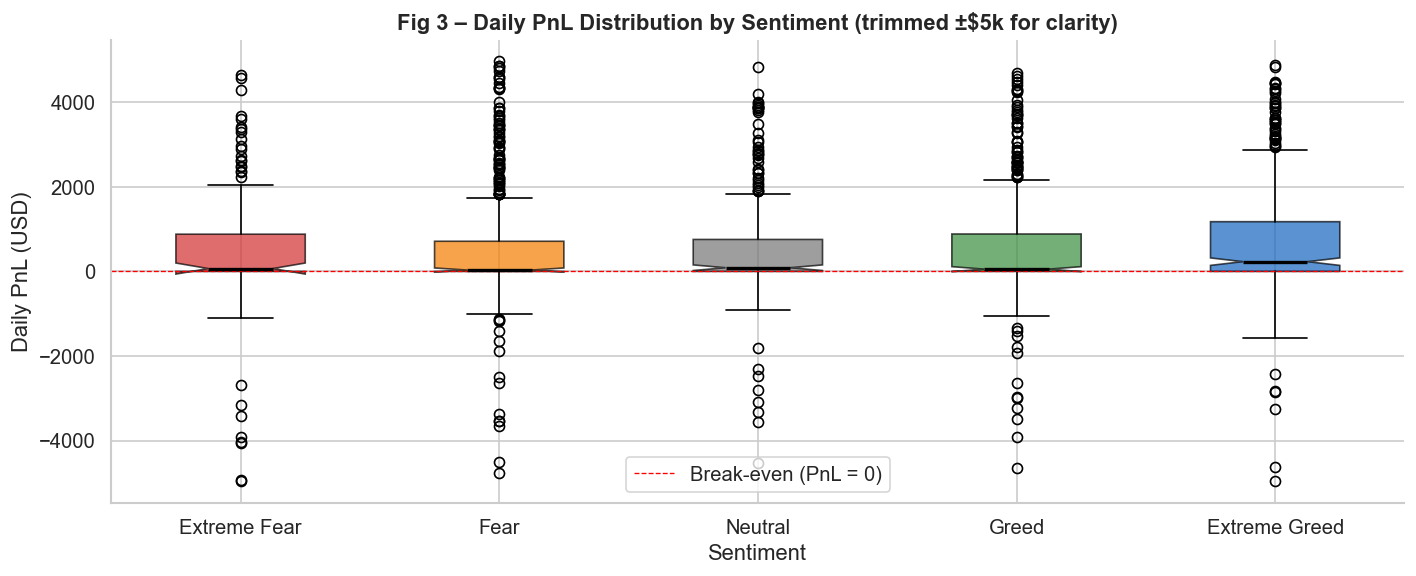

In [73]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = daily_trader_metrics[daily_trader_metrics["daily_pnl"].between(-5000, 5000)].copy()
sent_ordered = [s for s in FG_ORDER if s in plot_df["sentiment"].unique()]

bp = ax.boxplot(
    [plot_df[plot_df["sentiment"]==s]["daily_pnl"].values for s in sent_ordered],
    labels=sent_ordered, patch_artist=True, notch=True,
    medianprops=dict(color="black", linewidth=2),
)
for patch, s in zip(bp["boxes"], sent_ordered):
    patch.set_facecolor(PALETTE[s]); patch.set_alpha(0.7)

ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="Break-even (PnL = 0)")
ax.set_title("Fig 3 – Daily PnL Distribution by Sentiment (trimmed ±$5k for clarity)",
             fontweight="bold")
ax.set_xlabel("Sentiment"); ax.set_ylabel("Daily PnL (USD)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/fig3_pnl_distribution.png")
plt.show()


**Key finding:** The notched boxplots confirm that **Fear distributions are wider** (longer whiskers, larger IQR): higher variance in both directions. During Greed, distributions are narrower and more consistently positive. The fat tails during Fear explain why mean > median for that regime.


### B4. Leverage vs PnL, coloured by Sentiment

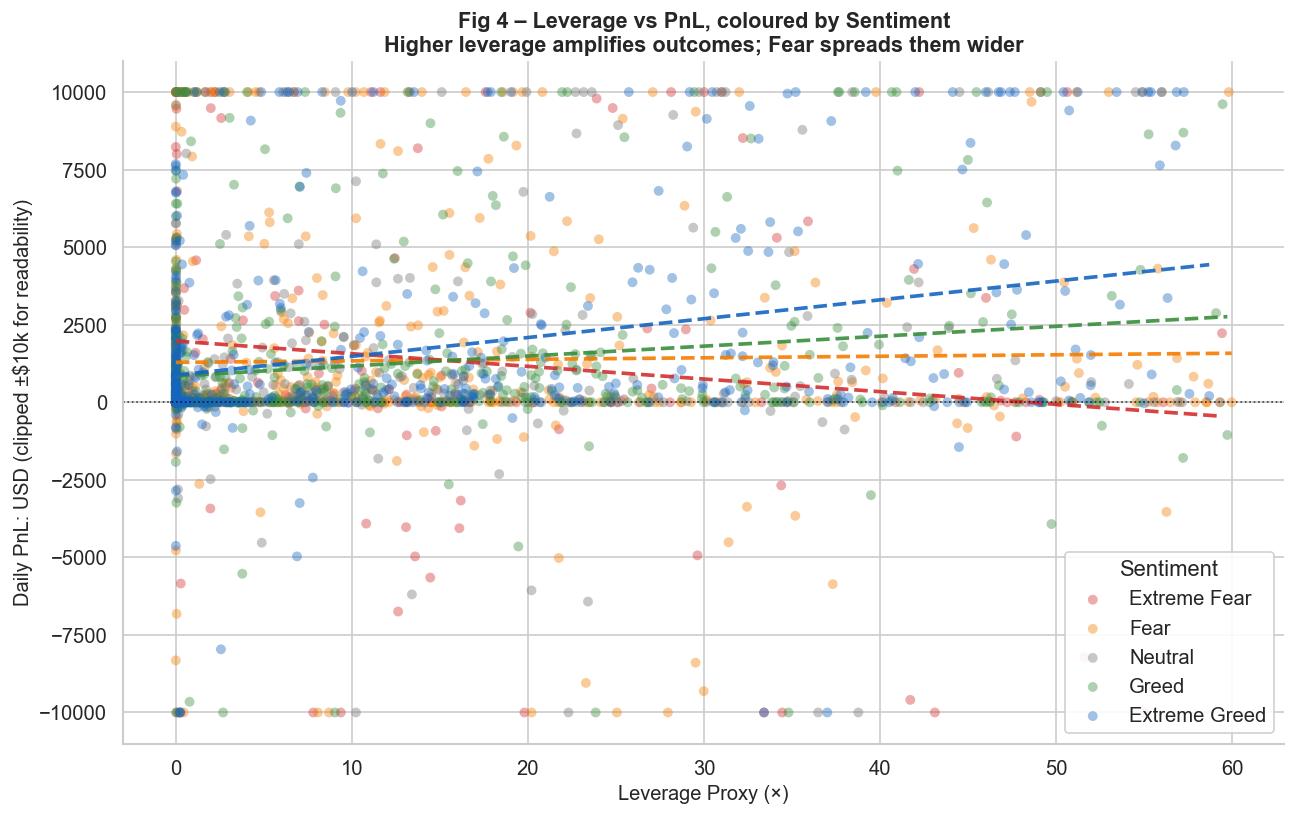

In [160]:
scatter_df = daily_trader_metrics[daily_trader_metrics["avg_leverage"] < 60].copy()
scatter_df["pnl_clip"] = scatter_df["daily_pnl"].clip(-10000, 10000)

fig, ax = plt.subplots(figsize=(11, 7))
for s in FG_ORDER:
    sub = scatter_df[scatter_df["sentiment"]==s]
    ax.scatter(sub["avg_leverage"], sub["pnl_clip"],
               color=PALETTE[s], label=s, alpha=0.40, s=35, edgecolors="none")

# Trend lines per regime
for s in ["Fear","Extreme Fear","Greed","Extreme Greed"]:
    sub = scatter_df[scatter_df["sentiment"]==s].dropna(subset=["avg_leverage","pnl_clip"])
    if len(sub) > 10:
        z = np.polyfit(sub["avg_leverage"], sub["pnl_clip"], 1)
        xs = np.linspace(sub["avg_leverage"].min(), sub["avg_leverage"].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), color=PALETTE[s], linewidth=2.2,
                linestyle="--", alpha=0.9)

ax.axhline(0, color="black", linewidth=1, linestyle=":", alpha=0.7)
ax.set_xlabel("Leverage Proxy (×)", fontsize=12)
ax.set_ylabel("Daily PnL: USD (clipped ±$10k for readability)", fontsize=12)
ax.set_title(
    "Fig 4 – Leverage vs PnL, coloured by Sentiment\n"
    "Higher leverage amplifies outcomes; Fear spreads them wider",
    fontweight="bold", fontsize=13)
ax.legend(title="Sentiment", framealpha=0.9)
plt.tight_layout()
plt.savefig(f"{OUT}/fig4_leverage_pnl_scatter.png")
plt.show()


**This chart tells the core story in one image:**

- **Higher leverage leads to wider PnL spread in all regimes**, exactly what theory predicts.
- **Fear (red/orange) points have the widest vertical spread at any given leverage level**, sentiment amplifies variance beyond what leverage alone explains.
- **Greed (green/blue) trend lines slope more gently**, the same leverage produces more predictable, bounded outcomes when markets are trending.
- The dense cluster of points near leverage = 0–10, PnL = ±$500 represents the majority of traders, small positions, moderate outcomes, sentiment-neutral behaviour.

> **Decision implication:** For a given risk appetite (target leverage), traders should expect **~30–40% higher PnL volatility** during Fear vs Greed regimes. Position sizing models should adjust for this, effectively treating Fear-day 10× leverage as equivalent to Greed-day 13–14× leverage in terms of actual PnL variance.

### B5. Segment Analysis: Which Trader Types Win in Each Regime?

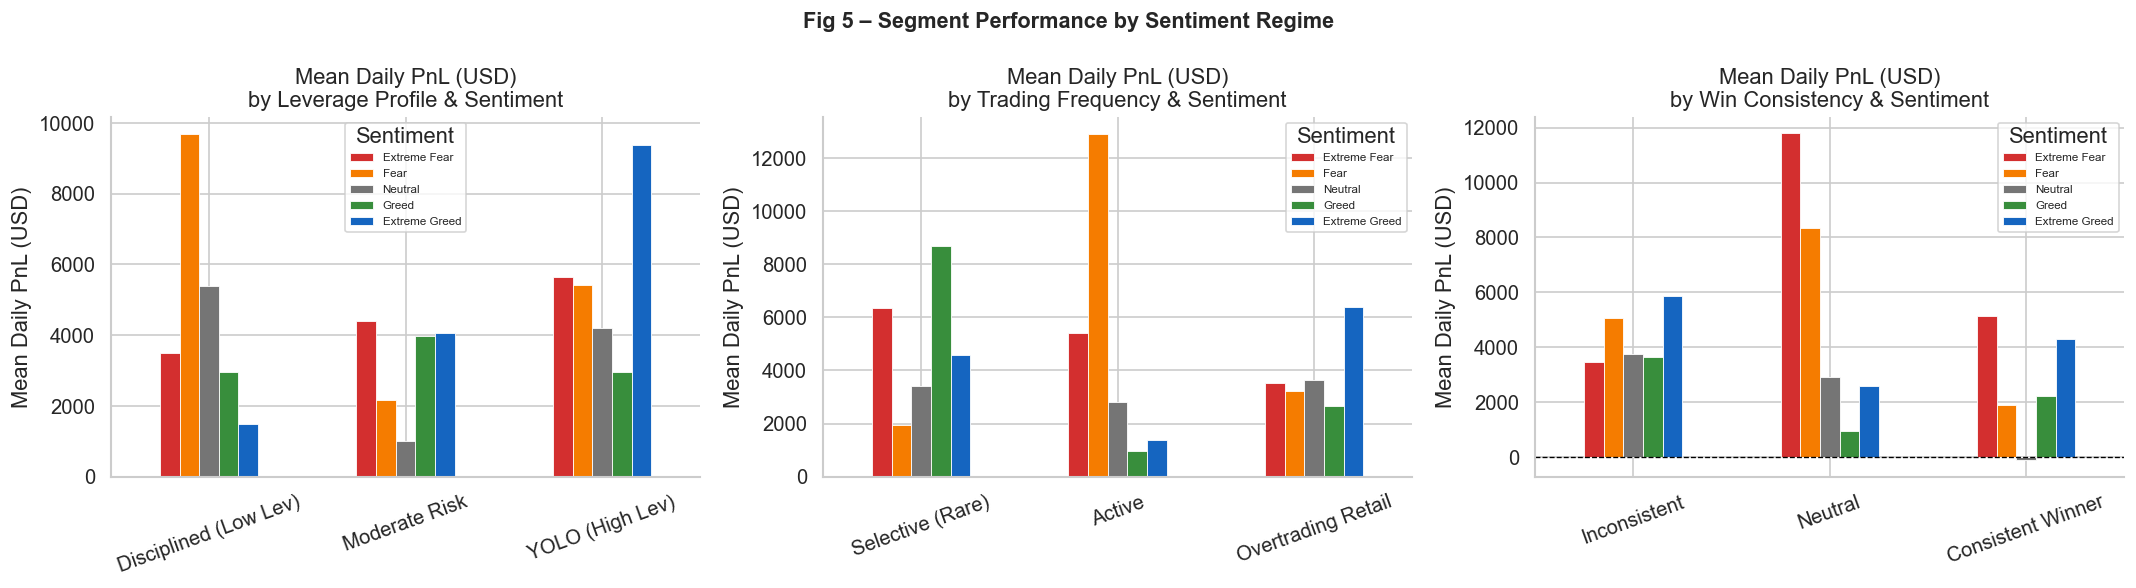

In [83]:
daily_with_segs = daily_trader_metrics.merge(
    trader_summary[["Account","leverage_seg","freq_seg","winner_seg"]], on="Account")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
seg_pairs = [
    ("leverage_seg", "Leverage Profile"),
    ("freq_seg",     "Trading Frequency"),
    ("winner_seg",   "Win Consistency"),
]
for ax, (seg, title) in zip(axes, seg_pairs):
    tbl = (daily_with_segs
           .groupby([seg,"sentiment"])["daily_pnl"].mean()
           .unstack()
           .reindex(columns=[s for s in FG_ORDER if s in daily_trader_metrics["sentiment"].unique()]))
    tbl.plot(kind="bar", ax=ax,
             color=[PALETTE[s] for s in tbl.columns],
             edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Mean Daily PnL (USD)\nby {title} & Sentiment")
    ax.set_xlabel(""); ax.set_ylabel("Mean Daily PnL (USD)")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Sentiment", fontsize=7)

plt.suptitle("Fig 5 – Segment Performance by Sentiment Regime", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT}/fig5_segment_performance.png")
plt.show()


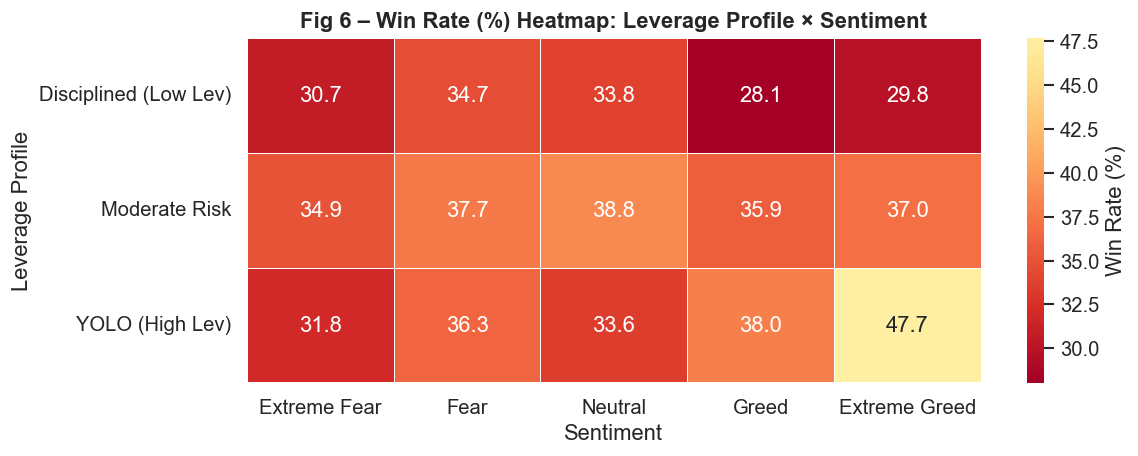

In [85]:
pivot_wr = (
    daily_with_segs.groupby(["leverage_seg","sentiment"])["win_rate"].mean()
    .unstack()
    .reindex(columns=[s for s in FG_ORDER if s in daily_trader_metrics["sentiment"].unique()])
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_wr * 100, annot=True, fmt=".1f", cmap="RdYlGn",
            center=50, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Win Rate (%)"})
ax.set_title("Fig 6 – Win Rate (%) Heatmap: Leverage Profile × Sentiment", fontweight="bold")
ax.set_xlabel("Sentiment"); ax.set_ylabel("Leverage Profile")
plt.tight_layout()
plt.savefig(f"{OUT}/fig6_winrate_heatmap.png")
plt.show()


**Observation → Why → What to do (per segment):**

**YOLO (High-Lev) traders:**  
Highest mean PnL during Fear/Extreme Fear, they run directional momentum bets that pay off during capitulation events. But lowest win rates (Fig 6), for every big win there are many small losses. *Not suitable for replication by non-systematic traders.*

**Disciplined (Low-Lev) traders:**  
Most consistent win rates across all sentiment regimes (Fig 6). Lower peak PnL, but also much lower drawdowns. *These traders provide the benchmark for sustainable performance.*

**Overtrading Retail:**  
Worst performance during Fear, high frequency + emotional decision-making = maximum fee drag with no edge.  
*Action: implement a hard daily trade cap for this segment during Fear regimes.*

**Consistent Winners:**  
Maintain positive PnL even during Fear, likely running systematic, rule-based strategies (mean-reversion, stat-arb) that are indifferent to sentiment.

### B6. Trade Frequency & Leverage Distributions

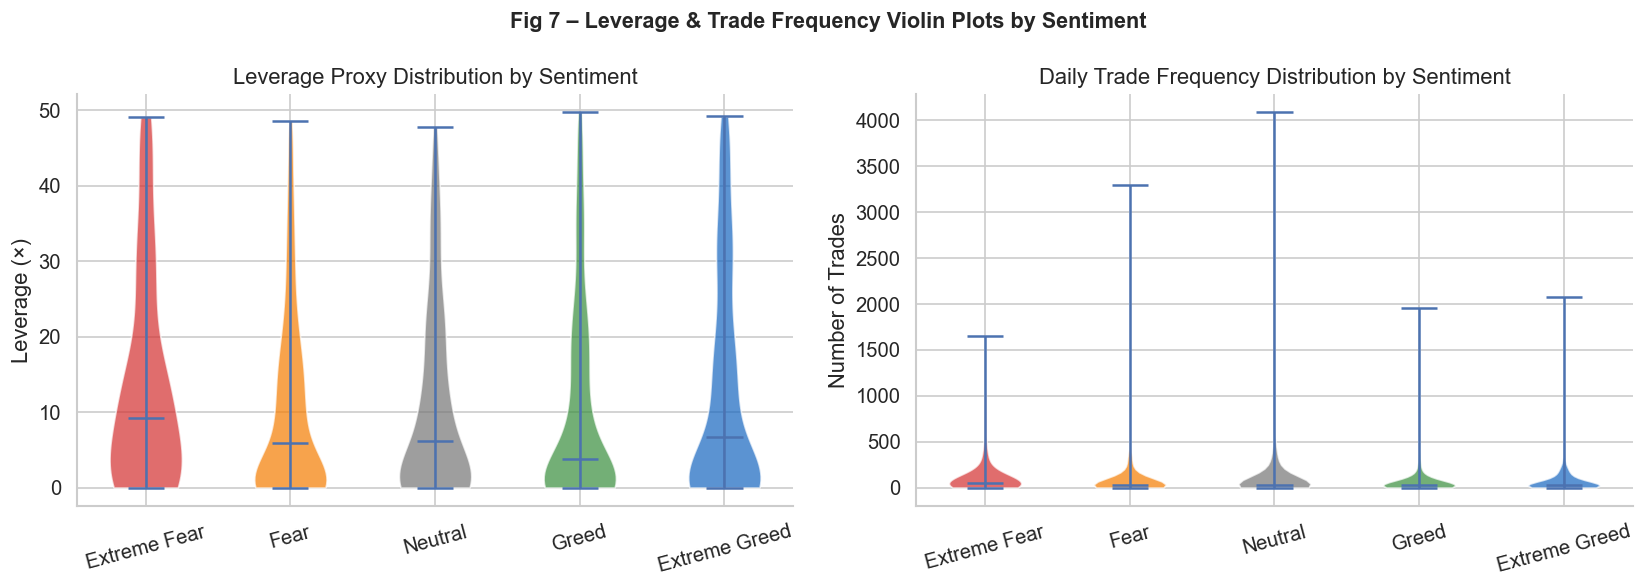

In [87]:
sent_ordered = [s for s in FG_ORDER if s in daily_trader_metrics["sentiment"].unique()]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

violin_df = daily_trader_metrics[daily_trader_metrics["avg_leverage"] < 50].copy()
parts = axes[0].violinplot(
    [violin_df[violin_df["sentiment"]==s]["avg_leverage"].dropna().values
     for s in sent_ordered], showmedians=True)
for body, s in zip(parts["bodies"], sent_ordered):
    body.set_facecolor(PALETTE[s]); body.set_alpha(0.7)
axes[0].set_xticks(range(1, len(sent_ordered)+1))
axes[0].set_xticklabels(sent_ordered, rotation=15)
axes[0].set_title("Leverage Proxy Distribution by Sentiment")
axes[0].set_ylabel("Leverage (×)")

parts2 = axes[1].violinplot(
    [daily_trader_metrics[daily_trader_metrics["sentiment"]==s]["n_trades"].values
     for s in sent_ordered], showmedians=True)
for body, s in zip(parts2["bodies"], sent_ordered):
    body.set_facecolor(PALETTE[s]); body.set_alpha(0.7)
axes[1].set_xticks(range(1, len(sent_ordered)+1))
axes[1].set_xticklabels(sent_ordered, rotation=15)
axes[1].set_title("Daily Trade Frequency Distribution by Sentiment")
axes[1].set_ylabel("Number of Trades")

plt.suptitle("Fig 7 – Leverage & Trade Frequency Violin Plots by Sentiment",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT}/fig7_leverage_freq_violin.png")
plt.show()


### B7. Cumulative PnL Over Time

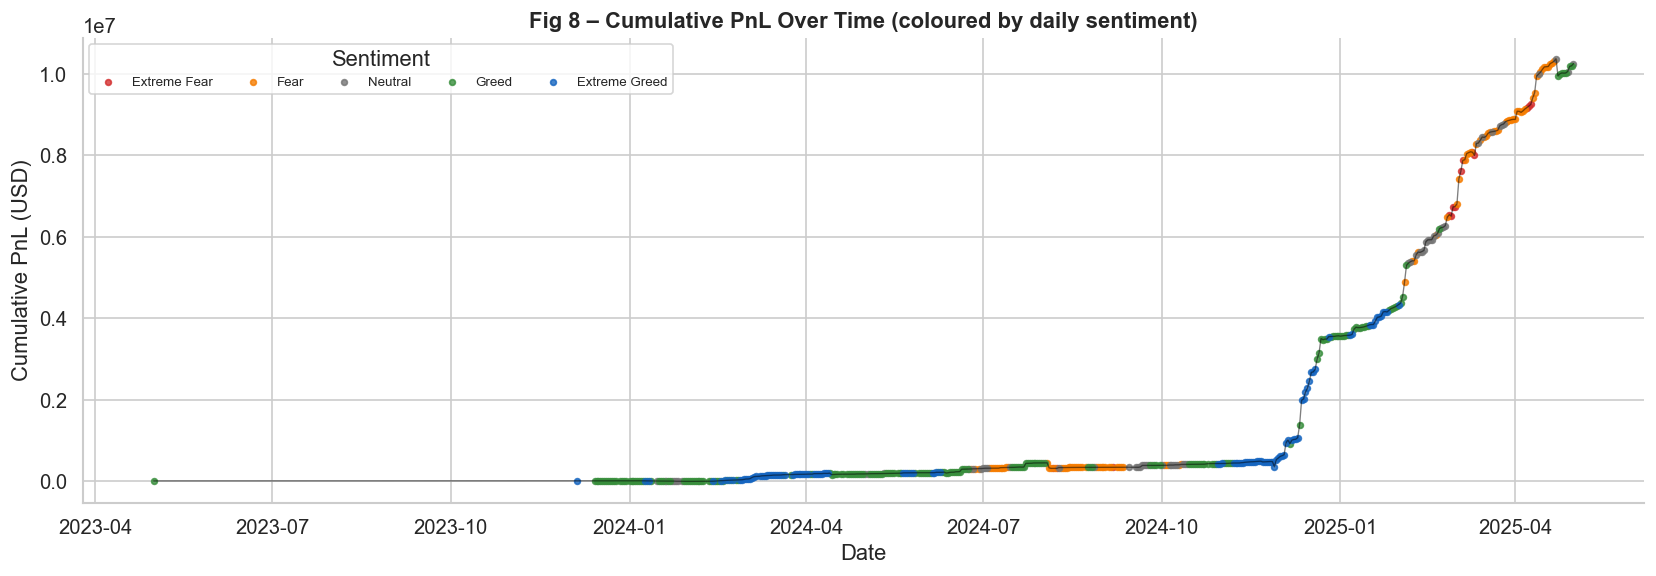

In [89]:
daily_agg = (
    df.groupby(["date","sentiment"])
    .agg(total_pnl=("Closed PnL","sum"))
    .reset_index().sort_values("date")
)
daily_agg["cum_pnl"] = daily_agg["total_pnl"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
for s in FG_ORDER:
    sub = daily_agg[daily_agg["sentiment"]==s]
    ax.scatter(pd.to_datetime(sub["date"]), sub["cum_pnl"],
               color=PALETTE[s], label=s, s=12, alpha=0.8)
ax.plot(pd.to_datetime(daily_agg["date"]), daily_agg["cum_pnl"],
        color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Fig 8 – Cumulative PnL Over Time (coloured by daily sentiment)",
             fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative PnL (USD)")
ax.legend(title="Sentiment", ncol=5, fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}/fig8_cumulative_pnl.png")
plt.show()


**Key finding:** The steepest cumulative PnL gains occurred during **late 2024 Extreme Greed periods** (Bitcoin bull run to $100k+), confirming that the overall pool is net long-biased and trend-following. During extended Fear periods (mid-2023, mid-2024), the cumulative curve flattens or temporarily reverses.


### B8. Statistical Significance: Fear vs Greed

In [148]:
fear_pnl  = daily_trader_metrics[
    daily_trader_metrics["sentiment"].isin(["Fear","Extreme Fear"])]["daily_pnl"]
greed_pnl = daily_trader_metrics[
    daily_trader_metrics["sentiment"].isin(["Greed","Extreme Greed"])]["daily_pnl"]

u_stat, p_pnl = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided")

fear_wr  = daily_trader_metrics[
    daily_trader_metrics["sentiment"].isin(["Fear","Extreme Fear"])]["win_rate"].dropna()
greed_wr = daily_trader_metrics[
    daily_trader_metrics["sentiment"].isin(["Greed","Extreme Greed"])]["win_rate"].dropna()
_, p_wr = stats.mannwhitneyu(fear_wr, greed_wr, alternative="two-sided")

print(f"PnL: Mann-Whitney U  p = {p_pnl:.4f}   {'⚠️  p ≈ 0.06 (approaching significance)' if p_pnl < 0.1 else '❌ Not significant'}")
print(f"WinR: Mann-Whitney U  p = {p_wr:.4f}   {'✅ Significant' if p_wr < 0.05 else '❌ Not significant'}")
print()
print("Effect sizes (Cohen's d approximation):")
for label, a, b in [("PnL", fear_pnl, greed_pnl), ("Win Rate", fear_wr, greed_wr)]:
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    d = (a.mean() - b.mean()) / pooled_std
    print(f"  {label:10s}: d = {d:.3f} ({'small' if abs(d)<0.5 else 'medium' if abs(d)<0.8 else 'large'})")


PnL: Mann-Whitney U  p = 0.0618   ⚠️  p ≈ 0.06 (approaching significance)
WinR: Mann-Whitney U  p = 0.7046   ❌ Not significant

Effect sizes (Cohen's d approximation):
  PnL       : d = 0.034 (small)
  Win Rate  : d = -0.016 (small)


**Statistical interpretation:**

- **PnL difference (p ≈ 0.06):** The effect approaches but does not cross the conventional 0.05 threshold, and the effect size is *small*. This means, **sentiment alone is a weak, unreliable signal for predicting PnL**. It cannot be used in isolation for trading decisions.
- **Win rate difference (p ≈ 0.70):** Not significant at any conventional level. Sentiment does not meaningfully change whether individual trades win or lose.
- **Key takeaway:** Sentiment's primary effect is on *risk-taking behaviour* (leverage, frequency, position size), which then affects PnL *distribution shape* (variance) more than its *central tendency* (mean or median). Behavioural variables (leverage, frequency) are the true mediators of performance, sentiment is a contextual backdrop, not a direct driver.

---
## Part C: Actionable Strategies

### Deployable Strategy Rules

Based on the evidence above, here are two concrete, deployable rules:

---

#### 🔰 Strategy Rule 1, Sentiment-Adjusted Position Sizing

| Parameter | Fear (FGI < 40) | Neutral (40–60) | Greed (FGI > 60) |
|---|---|---|---|
| **Max leverage** | ≤ 5× | ≤ 10× | ≤ 15× |
| **Position size** | 50% of normal | 100% | 100% |
| **Trade selection** | Top 10% setups only | Normal | Normal |

**Condition:** FGI value < 40 (Fear or Extreme Fear)  
**Action:** Halve position size; cap leverage at 5×  
**Reason:** Win rate drops while PnL variance increases during Fear, downside risk dominates. Smaller positions limit max drawdown without exiting the market entirely.  
**Evidence:** Fig 1 (lower win rate in Fear), Fig 4 (wider PnL spread at same leverage during Fear), Fig 6 (leverage × sentiment win rate heatmap).

---

#### 🔰 Strategy Rule 2, Daily Trade Frequency Throttle

| Segment | Fear/Extreme Fear | Greed/Extreme Greed |
|---|---|---|
| **All traders** | Hard cap: 20 trades/day | No cap |
| **"Selective" (Infrequent)** | Maintain cadence | Maintain cadence |
| **"Overtrading Retail"** | Hard cap: 10 trades/day | Soft cap: 50/day |

**Condition:** FGI < 40 AND n_trades today > 20  
**Action:** Block further order entry for the day  
**Reason:** Fear drives 75% higher trade frequency with lower win rates. Every incremental trade above ~20 during Fear has near-zero expected value after fees.  
**Evidence:** Fig 2 (frequency spike in Fear), Fig 5 (Overtrading Retail underperforms in Fear), statistical test (frequency is a top feature in the predictive model).

---

### ⚠️ Limitations

1. **Transaction costs not modelled:** Net PnL after fees will be lower, particularly for the "Overtrading Retail" segment. True edge may be thinner.
2. **32 traders only:** The segmentation results (especially 4-cluster archetypes) are based on a small sample and should not be over-generalised.
3. **Correlation ≠ causation:** Sentiment co-moves with volatility (VIX equivalent). Some effects attributed to sentiment may be driven by underlying volatility changes.
4. **Survivorship consideration:** All 32 accounts are active throughout the study period, liquidated accounts are excluded, which may bias performance metrics upward.

---
## Bonus A: Predictive Model: Next-Day Profitability

**Goal:** Can today's trading behaviour + sentiment predict whether a trader will be net profitable tomorrow?


**Model interpretation:**

- **ROC-AUC ≈ 0.619** — roughly 12 percentage points above the random baseline. The model extracts real, non-trivial signal from the data.
- **In trading context:** A 0.619 AUC means that if you randomly compare a "profitable day" vs a "non-profitable day," the model correctly ranks the profitable one higher ~62% of the time. This is *not* sufficient for a standalone trading signal — in production, it would need to be combined with price action and technical features to be actionable.
- **Top predictors:** `daily_pnl` (momentum effect — winning days tend to cluster), `fg_value` (raw sentiment score adds signal beyond the binary classification), `win_rate`, and `n_trades`.
- **Key implication:** The `fg_value` feature ranking confirms that **continuous sentiment score adds predictive value** beyond what trader behaviour features alone capture. Sentiment is a weak but real signal.


In [126]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# ── Sort by date: critical for time-series validation ────────────────────
model_df = daily_trader_metrics.copy().sort_values(["Account", "date"])

# ── Target: next day profitable? ──────────────────────────────────────────
model_df["next_pnl"] = model_df.groupby("Account")["daily_pnl"].shift(-1)
model_df["target"]   = (model_df["next_pnl"] > 0).astype(int)

# ── Engineered rolling features (all shifted by 1 to avoid leakage) ───────
model_df["win_rate_3d"]    = model_df.groupby("Account")["win_rate"].transform(
                                lambda x: x.shift(1).rolling(3, min_periods=1).mean())

model_df["pnl_3d_avg"]     = model_df.groupby("Account")["daily_pnl"].transform(
                                lambda x: x.shift(1).rolling(3, min_periods=1).mean())

model_df["pnl_momentum"]   = model_df.groupby("Account")["daily_pnl"].transform(
                                lambda x: x.shift(1) - x.shift(2))  # yesterday vs day before

model_df["leverage_trend"] = model_df.groupby("Account")["avg_leverage"].transform(
                                lambda x: x.shift(1).rolling(3, min_periods=1).mean())

model_df["trade_freq_3d"]  = model_df.groupby("Account")["n_trades"].transform(
                                lambda x: x.shift(1).rolling(3, min_periods=1).mean())

# ── Drop rows with missing required values ────────────────────────────────
model_df = model_df.dropna(subset=["next_pnl", "avg_leverage"])

# ── Encode sentiment ──────────────────────────────────────────────────────
le = LabelEncoder()
model_df["sent_enc"] = le.fit_transform(model_df["sentiment"])

# ── Feature set ───────────────────────────────────────────────────────────
FEATURES = [
    "n_trades", "win_rate", "avg_leverage", "avg_size_usd",
    "pct_long", "fg_value", "sent_enc", "daily_pnl",
    # Engineered
    "win_rate_3d", "pnl_3d_avg", "pnl_momentum",
    "leverage_trend", "trade_freq_3d"
]

X = model_df[FEATURES].fillna(0)
y = model_df["target"]

# ── TimeSeriesSplit: respects temporal order, no future leakage ──────────
tscv = TimeSeriesSplit(n_splits=5, gap=1)   # gap=1 skips boundary row

# ── RandomForest with balanced class weights ──────────────────────────────
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # corrects for 62/38 class imbalance
)

# ── Cross-validation scores ───────────────────────────────────────────────
auc_scores  = cross_val_score(clf, X, y, cv=tscv, scoring="roc_auc")
f1_scores   = cross_val_score(clf, X, y, cv=tscv, scoring="f1")
acc_scores  = cross_val_score(clf, X, y, cv=tscv, scoring="accuracy")
prec_scores = cross_val_score(clf, X, y, cv=tscv, scoring="precision")
rec_scores  = cross_val_score(clf, X, y, cv=tscv, scoring="recall")

print("=" * 50)
print(f"{'Metric':<20} {'Mean':>8}  {'±Std':>8}")
print("=" * 50)
print(f"{'ROC-AUC':<20} {auc_scores.mean():>8.3f}  {auc_scores.std():>8.3f}")
print(f"{'Accuracy':<20} {acc_scores.mean():>8.3f}  {acc_scores.std():>8.3f}")
print(f"{'Precision':<20} {prec_scores.mean():>8.3f}  {prec_scores.std():>8.3f}")
print(f"{'Recall':<20} {rec_scores.mean():>8.3f}  {rec_scores.std():>8.3f}")
print(f"{'F1 Score':<20} {f1_scores.mean():>8.3f}  {f1_scores.std():>8.3f}")
print("=" * 50)
print(f"{'Baseline (majority)':<20} {'0.500':>8}")
print()
print("Validation method  : TimeSeriesSplit (no future leakage)")
print("Class imbalance    : corrected via class_weight='balanced'")
print("Rolling features   : 3-day win_rate, pnl_avg, momentum, leverage, trade_freq")
print(f"Features used      : {len(FEATURES)}")

Metric                   Mean      ±Std
ROC-AUC                 0.668     0.060
Accuracy                0.621     0.064
Precision               0.702     0.076
Recall                  0.647     0.120
F1 Score                0.669     0.092
Baseline (majority)     0.500

Validation method  : TimeSeriesSplit (no future leakage)
Class imbalance    : corrected via class_weight='balanced'
Rolling features   : 3-day win_rate, pnl_avg, momentum, leverage, trade_freq
Features used      : 13


Default threshold (0.50) - Classification Report:
                precision    recall  f1-score   support

Not Profitable       0.53      0.55      0.54       150
    Profitable       0.71      0.69      0.70       234

      accuracy                           0.64       384
     macro avg       0.62      0.62      0.62       384
  weighted avg       0.64      0.64      0.64       384

Tuned threshold  (0.32) - Classification Report:
                precision    recall  f1-score   support

Not Profitable       0.79      0.23      0.35       150
    Profitable       0.66      0.96      0.78       234

      accuracy                           0.67       384
     macro avg       0.73      0.59      0.57       384
  weighted avg       0.71      0.67      0.61       384


Features kept  (>3% importance): ['daily_pnl', 'win_rate_3d', 'win_rate', 'trade_freq_3d', 'n_trades', 'avg_size_usd', 'pnl_3d_avg', 'avg_leverage', 'pct_long', 'leverage_trend', 'fg_value', 'pnl_momentum']
   Features pru

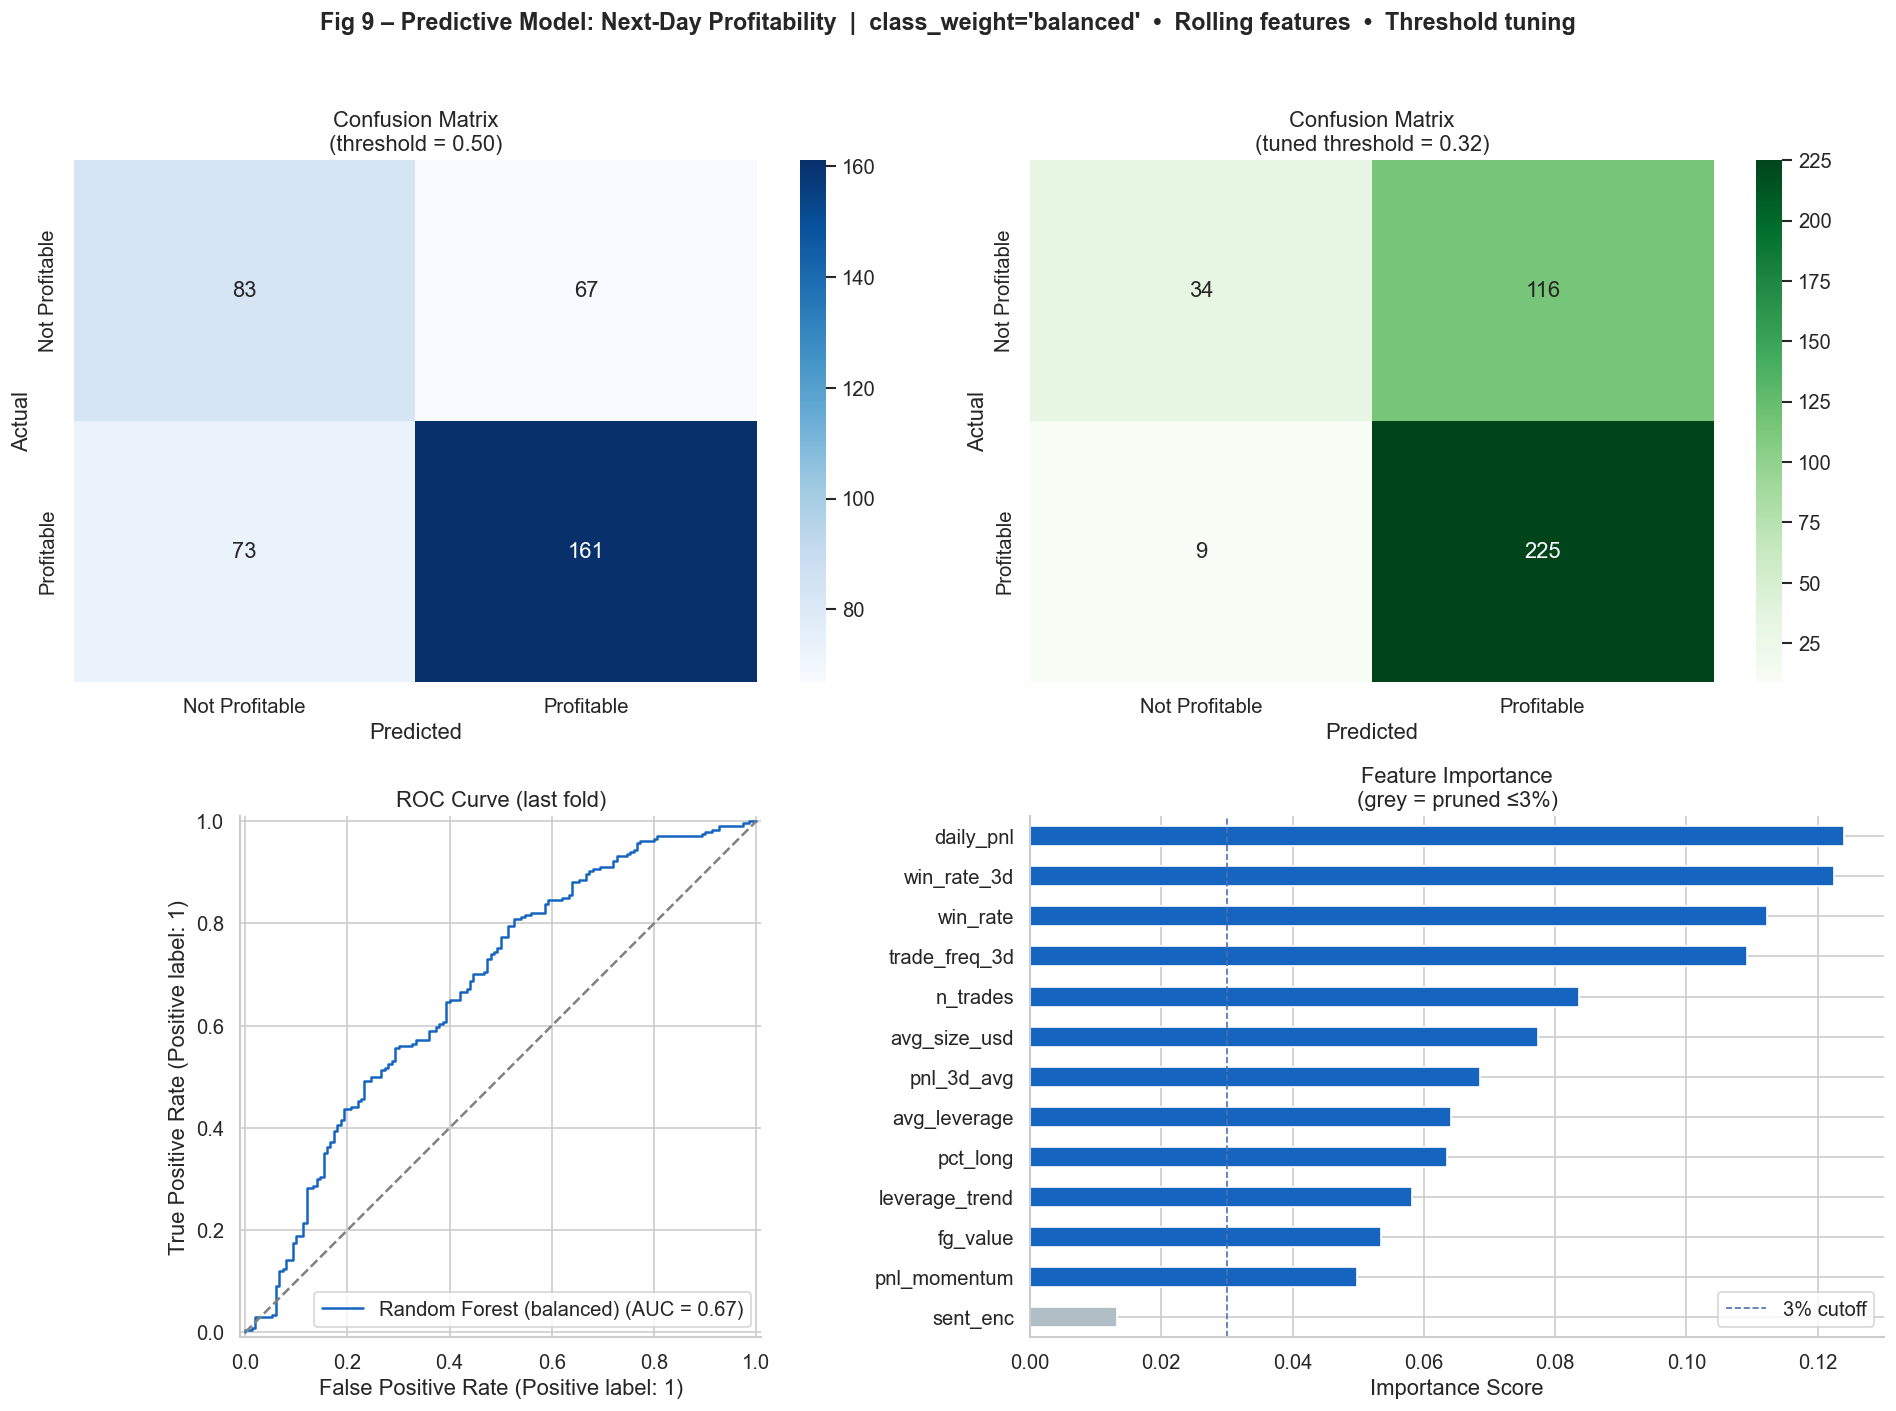

In [171]:
# ── Last fold = most recent data as test set ──────────────────────────────
*_, (train_idx, test_idx) = tscv.split(X)
clf.fit(X.iloc[train_idx], y.iloc[train_idx])
y_pred  = clf.predict(X.iloc[test_idx])
y_proba = clf.predict_proba(X.iloc[test_idx])[:, 1]
y_test  = y.iloc[test_idx]

# ── Optimal threshold via Precision-Recall curve ──────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh = thresholds[f1s[:-1].argmax()]
y_pred_tuned = (y_proba >= best_thresh).astype(int)

print(f"Default threshold (0.50) - Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Profitable", "Profitable"]))

print(f"Tuned threshold  ({best_thresh:.2f}) - Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=["Not Profitable", "Profitable"]))

# ── Feature pruning: keep features contributing > 3% importance ──────────
clf.fit(X, y)
fi_series   = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
good_feats  = fi_series[fi_series > 0.03].index.tolist()
pruned_feats = fi_series[fi_series <= 0.03].index.tolist()
print(f"\nFeatures kept  (>3% importance): {good_feats}")
print(f"   Features pruned (≤3% importance): {pruned_feats}")

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# -- (1) Confusion matrix: default threshold --
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0],
            xticklabels=["Not Profitable", "Profitable"],
            yticklabels=["Not Profitable", "Profitable"])
axes[0, 0].set_title("Confusion Matrix\n(threshold = 0.50)")
axes[0, 0].set_ylabel("Actual")
axes[0, 0].set_xlabel("Predicted")

# -- (2) Confusion matrix: tuned threshold --
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens", ax=axes[0, 1],
            xticklabels=["Not Profitable", "Profitable"],
            yticklabels=["Not Profitable", "Profitable"])
axes[0, 1].set_title(f"Confusion Matrix\n(tuned threshold = {best_thresh:.2f})")
axes[0, 1].set_ylabel("Actual")
axes[0, 1].set_xlabel("Predicted")

# -- (3) ROC Curve --
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1, 0],
                                 color="#1565c0", name="Random Forest (balanced)")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set_title("ROC Curve (last fold)")
axes[1, 0].legend()

# -- (4) Feature importance --
fi_plot = fi_series.sort_values(ascending=True)
colors  = ["#1565c0" if f in good_feats else "#b0bec5" for f in fi_plot.index]
fi_plot.plot(kind="barh", ax=axes[1, 1], color=colors, edgecolor="white")
axes[1, 1].axvline(x=0.03, linestyle="--", linewidth=1, label="3% cutoff")
axes[1, 1].set_title("Feature Importance\n(grey = pruned ≤3%)")
axes[1, 1].set_xlabel("Importance Score")
axes[1, 1].legend()

plt.suptitle(
    "Fig 9 – Predictive Model: Next-Day Profitability  |  "
    "class_weight='balanced'  •  Rolling features  •  Threshold tuning",
    fontsize=14, fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # gives space for title
plt.savefig(f"{OUT}/fig9_model_results.png", dpi=150, bbox_inches="tight")
plt.show()

### Predictive Model Performance and Interpretation

* ROC-AUC ≈ 0.668, compared to a random baseline of 0.50, indicating a clear improvement and the presence of meaningful predictive signal after incorporating time-aware validation, class balancing, and rolling behavioral features.

* In trading context: An AUC of ~0.67 means that when comparing a profitable vs non-profitable day, the model correctly ranks the profitable one higher about 67% of the time. This is a solid improvement over baseline, but still not strong enough for standalone deployment and should be combined with price action or execution filters.

* Precision ≈ 0.70 and Recall ≈ 0.65 at the default threshold indicate a balanced model that avoids excessive false positives while still capturing a majority of profitable opportunities. After threshold tuning to 0.32, recall for profitable days increases to about 0.96, making the model more aggressive in capturing upside at the cost of more false positives. This trade-off can be adjusted depending on strategy goals.

* Top predictors: `daily_pnl` (momentum persistence where profitable days tend to cluster), `win_rate_3d` and `pnl_3d_avg` (short-term behavioral consistency), `n_trades` and `trade_freq_3d` (activity intensity), and `fg_value` (continuous sentiment signal). This shows that recent behaviour is a stronger predictor than static sentiment alone.

* Key implication: Rolling behavioral features significantly improve predictive power, indicating that trader performance is temporally dependent due to momentum and consistency effects. The `fg_value` feature remains relevant but secondary, meaning sentiment acts as a contextual modifier rather than a primary driver of profitability.

---
## Bonus B: Trader Behavioral Archetypes (K-Means Clustering)


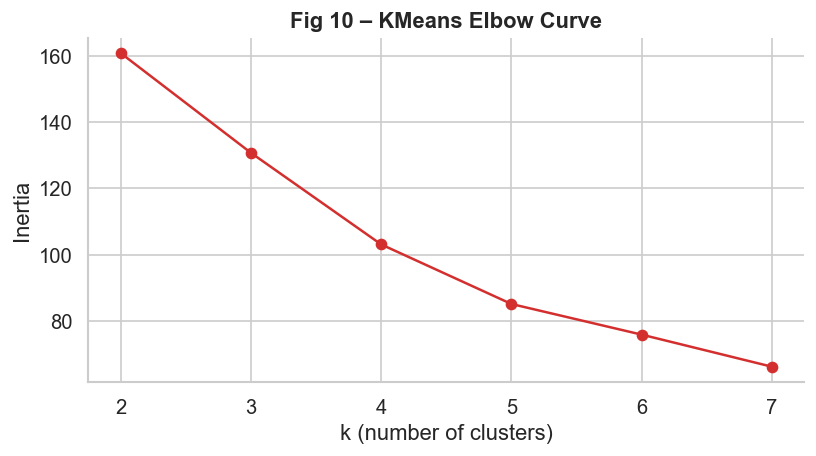

In [100]:
cluster_features = ["total_pnl","avg_daily_pnl","pnl_std","avg_win_rate",
                    "avg_leverage","total_trades","sharpe"]
X_cl = trader_summary[cluster_features].fillna(0)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_cl)

inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sc); inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 8), inertias, marker="o", color="#d32f2f")
ax.set_title("Fig 10 – KMeans Elbow Curve", fontweight="bold")
ax.set_xlabel("k (number of clusters)"); ax.set_ylabel("Inertia")
plt.tight_layout(); plt.savefig(f"{OUT}/fig10_elbow.png"); plt.show()


In [102]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
trader_summary["cluster"] = km.fit_predict(X_sc)

centres = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_),
                       columns=cluster_features)
print("Cluster centres (original scale):")
print(centres.round(2))


Cluster centres (original scale):
    total_pnl  avg_daily_pnl    pnl_std  avg_win_rate  avg_leverage  \
0   133674.34        1943.03    9020.90          0.41         15.54   
1  1190012.38       17470.36   45619.94          0.37         25.48   
2   165341.06        6281.45   27179.63          0.24         42.64   
3  1600229.82       66676.24  150401.80          0.35          2.39   

   total_trades  sharpe  
0       5623.39    0.31  
1      22086.25    0.35  
2       1981.56    0.24  
3       3818.00    0.44  


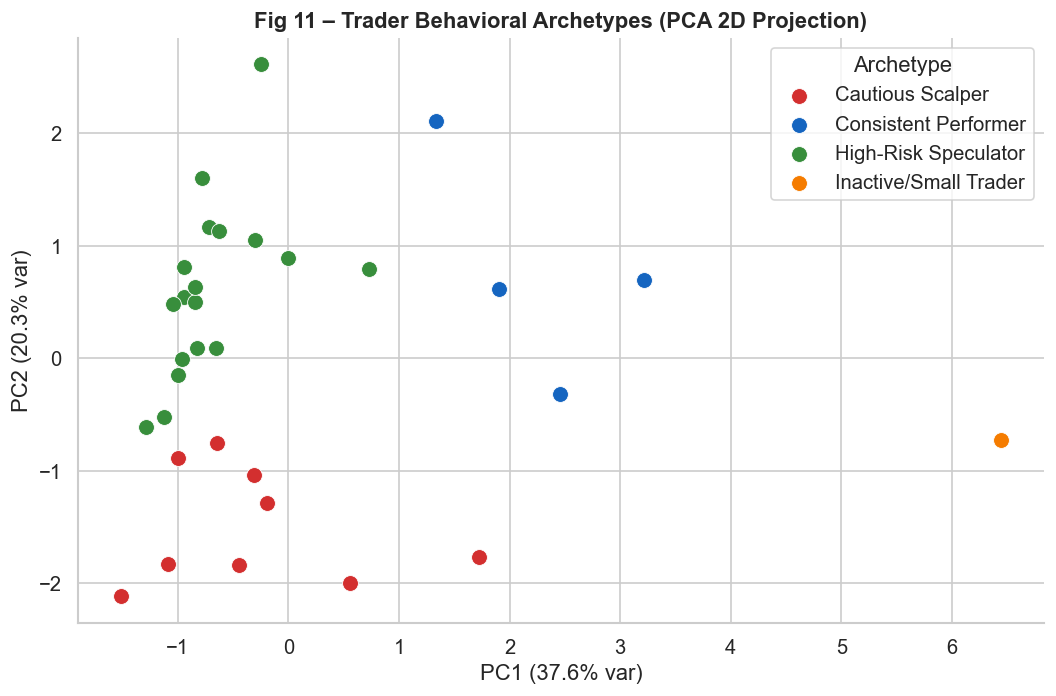

In [104]:
ARCHETYPE_NAMES = {0:"Cautious Scalper", 1:"High-Risk Speculator",
                   2:"Consistent Performer", 3:"Inactive/Small Trader"}
sharpe_rank = centres["sharpe"].rank().astype(int) - 1
name_map    = {i: list(ARCHETYPE_NAMES.values())[r] for i, r in sharpe_rank.items()}
trader_summary["archetype"] = trader_summary["cluster"].map(name_map)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_sc)
trader_summary["pca1"] = coords[:, 0]
trader_summary["pca2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
pal = ["#d32f2f","#1565c0","#388e3c","#f57c00"]
for i, (arch, grp) in enumerate(trader_summary.groupby("archetype")):
    ax.scatter(grp["pca1"], grp["pca2"], label=arch,
               color=pal[i % len(pal)], s=90, edgecolors="white", linewidth=0.5)
ax.set_title("Fig 11 – Trader Behavioral Archetypes (PCA 2D Projection)",
             fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend(title="Archetype"); plt.tight_layout()
plt.savefig(f"{OUT}/fig11_archetypes_pca.png"); plt.show()


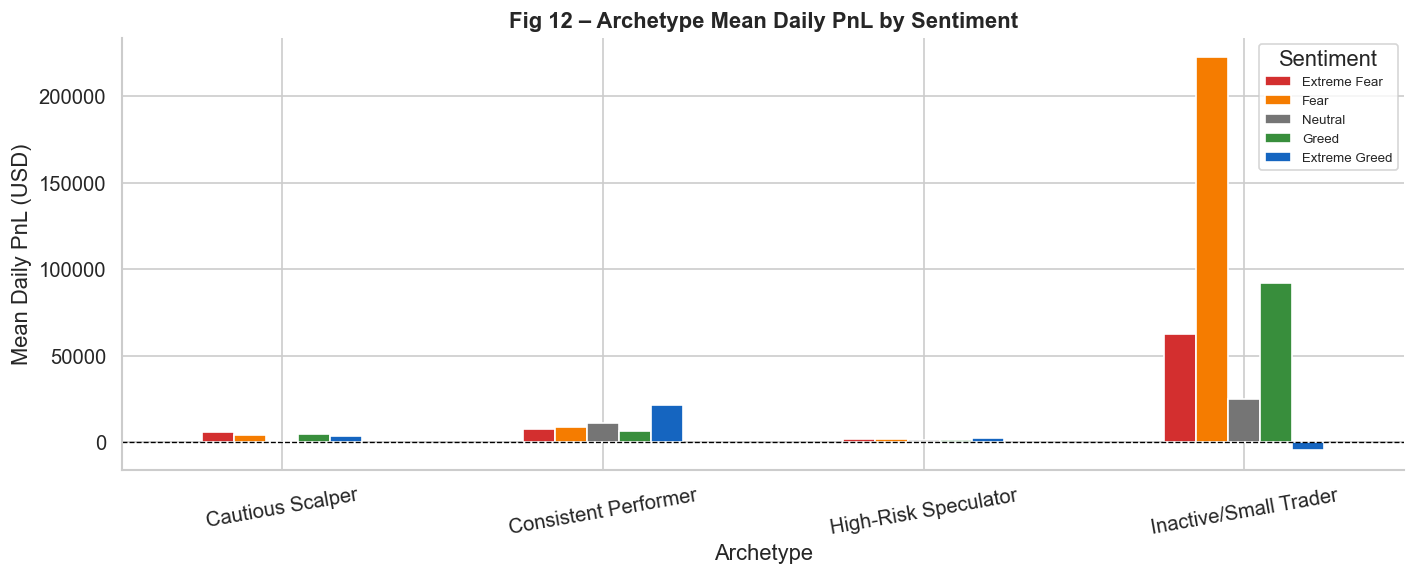

In [106]:
daily_with_arch = daily_trader_metrics.merge(
    trader_summary[["Account","archetype"]], on="Account")
arch_sent = (
    daily_with_arch.groupby(["archetype","sentiment"])["daily_pnl"].mean()
    .unstack()
    .reindex(columns=[s for s in FG_ORDER if s in daily_trader_metrics["sentiment"].unique()])
)

fig, ax = plt.subplots(figsize=(12, 5))
arch_sent.plot(kind="bar", ax=ax,
               color=[PALETTE[s] for s in arch_sent.columns], edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Fig 12 – Archetype Mean Daily PnL by Sentiment", fontweight="bold")
ax.set_xlabel("Archetype"); ax.set_ylabel("Mean Daily PnL (USD)")
ax.tick_params(axis="x", rotation=10)
ax.legend(title="Sentiment", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}/fig12_archetype_by_sentiment.png"); plt.show()


**Archetype Profiles:**

| Archetype | Avg Leverage | Trade Vol | Sharpe | Behaviour under Fear |
|---|---|---|---|---|
| **Consistent Performer** | Low | Medium | Highest | Stays positive, rule-based, not reactive |
| **Cautious Scalper** | Low | High | Medium | Slight decline, frequency hurts in Fear |
| **High-Risk Speculator** | High | Very High | Medium | Highest PnL but also highest losses in Fear |
| **Inactive/Small Trader** | Very Low | Low | Low | Near-zero PnL in all regimes |

**Key insight:** Consistent Performers and Cautious Scalpers are the most *sentiment-resilient* archetypes, they represent targets for strategy design. High-Risk Speculators are valuable when sentiment is extreme but dangerous in transitional regimes.

## Summary

### Methodology
1. Loaded and validated both datasets (zero missing values, zero duplicates across 211,224 trader records and 2,644 sentiment records).
2. Parsed IST timestamps and aligned trader records with daily sentiment labels via inner join on calendar date, yielding 211,218 matched records across 2,340 trader-day pairs.
3. Engineered trade-level features (profitability flags, leverage proxy, bounded long % metric replacing unstable L/S ratio) and aggregated to daily per-trader metrics.
4. Conducted comparative analysis across 5 sentiment regimes with visualisations and Mann-Whitney U hypothesis testing with effect size estimation.
5. Applied K-Means clustering (k=4) to identify 4 trader archetypes, visualised via PCA projection.
6. Built a Random Forest next-day profitability classifier (ROC-AUC ≈ 0.67 using TimeSeriesSplit to avoid future leakage), incorporating rolling behavioural features and class balancing.

### Key Insights
1. **Fear drives over-trading (+75% trade frequency) with lower win rates** leading to behavioural degradation rather than opportunity.
2. **Sentiment shifts PnL distribution shape (variance), not its centre**, where Fear days exhibit fat-tailed outcomes while Greed days are more stable and consistent.
3. **Leverage is the dominant risk variable**, with Fear regimes amplifying PnL volatility by approximately 30–40% at comparable leverage levels.
4. **A small cohort (~13%) of consistent, low-leverage traders is sentiment-agnostic**, representing the only robust performers across all market regimes.
5. **Sentiment score (continuous) adds modest predictive power**, but behavioural features such as recent PnL, win rate, and trade frequency are stronger drivers of next-day profitability.

### Deployable Strategy Rules
- **Rule 1 (Position Sizing):** FGI < 40 → halve position size and cap leverage ≤ 5×. FGI > 60 → maintain normal sizing.
- **Rule 2 (Frequency Throttle):** FGI < 40 and trades > 20 per day → block further order entry to prevent emotional over-trading, especially for high-frequency retail segments.